In [1]:
import numpy as np
import matplotlib.pyplot as plt
import models
import pandas as pd

In [2]:
df = pd.read_csv(
'https://archive.ics.uci.edu/ml/'
'machine-learning-databases/iris/iris.data',
header=None, encoding='utf-8')

df_wine = pd.read_csv(
'https://archive.ics.uci.edu/ml/'
'machine-learning-databases/wine/wine.data',
header=None
)

In [3]:
#  Question 3: Multi class classification using OvR strategy 
X = df.iloc[:, 0:4].values
y = df.iloc[:, 4].values
multi_model = models.MultiClassAdalineGD(models.AdalineGD, 0.01, 500)
multi_model.fit(X,y)
y_test = multi_model.predict(X)
(y == y_test).sum()



np.int64(125)

In [4]:
# Question 4: Comparing GD, SDS and mini-batch SHD
gd_model = models.LogisticRegressionGD(0.05, 500)
sgd_model = models.LogisticRegressionGD(0.05, 500, 1, True, 1)
msgd_model = models.LogisticRegressionGD(0.05, 500)
X = df_wine.iloc[0:130, 1:].values
X = (X - X.mean())/X.std()
y = df_wine.iloc[0:130, 0].values
y = np.where(y == 1, 1, 0)

time_gd = np.zeros(gd_model.n_iter)
time_sgd = np.zeros(sgd_model.n_iter)
time_msgd = np.zeros(msgd_model.n_iter)
for _ in range(5):
    gd_model.fit(X, y)
    sgd_model.fit_mini_batch_SGD(X, y)
    msgd_model.fit_mini_batch_SGD(X, y)
    time_gd = time_gd + gd_model.elasped_time
    time_sgd = time_sgd + sgd_model.elasped_time
    time_msgd = time_msgd + msgd_model.elasped_time

time_gd = time_gd / 5
time_sgd = time_sgd / 5
time_msgd = time_msgd / 5


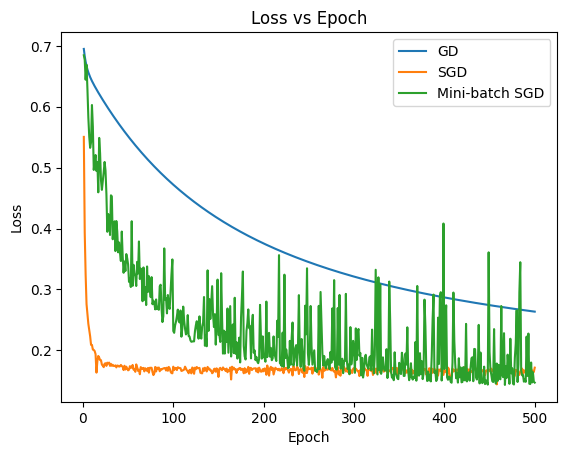

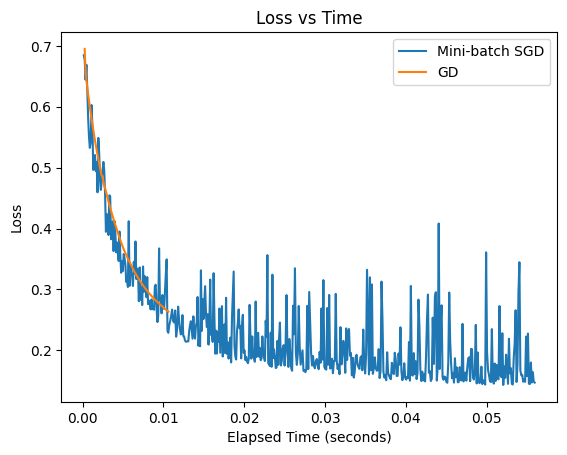

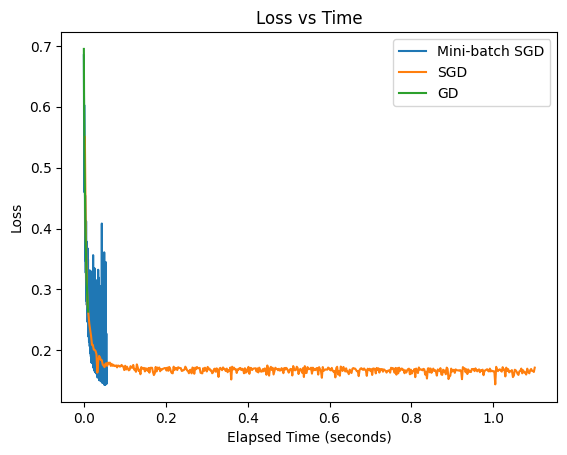

In [5]:
plt.plot(range(1, gd_model.n_iter + 1), gd_model.losses_, label="GD")
plt.plot(range(1, sgd_model.n_iter + 1), sgd_model.losses_, label="SGD")
plt.plot(range(1, msgd_model.n_iter + 1), msgd_model.losses_, label="Mini-batch SGD")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

plt.plot(time_msgd, msgd_model.losses_, label="Mini-batch SGD")
plt.plot(time_gd, gd_model.losses_, label="GD")
plt.xlabel("Elapsed Time (seconds)")
plt.ylabel("Loss")
plt.title("Loss vs Time")
plt.legend()
plt.show()

plt.plot(time_msgd, msgd_model.losses_, label="Mini-batch SGD")
plt.plot(time_sgd, sgd_model.losses_, label="SGD")
plt.plot(time_gd, gd_model.losses_, label="GD")
plt.xlabel("Elapsed Time (seconds)")
plt.ylabel("Loss")
plt.title("Loss vs Time")
plt.legend()
plt.show()